# **Proyecto Integrador de Aprendizaje Automático — KNN (Clasificación y Regresión)**

## **Objetivo:**  

Desarrollar y evaluar modelos basados en el algoritmo K-Nearest Neighbors (KNN) para abordar dos problemas distintos dentro del contexto académico universitario:

- *Clasificación:* predecir la probabilidad de que un estudiante abandone sus estudios, utilizando como variable objetivo Target (binaria: abandono/no abandono).

- *Regresión:* estimar el rendimiento académico de los estudiantes a través de la variable Curricular 'promedio_final' que se crea durante el proceso de preprocesamiento e indica el promedio entre las variables 'Curricular units 1st sem (grade)' y 'Curricular units 2nd sem (grade)'.

El propósito es identificar el valor de k que ofrezca el mejor equilibrio entre precisión y capacidad predictiva en cada tarea, analizar el impacto de este parámetro en el rendimiento del modelo, y reflexionar sobre las ventajas y limitaciones de KNN en contextos educativos.

## **Restricciones:**  
- Sin `GridSearchCV` (validación manual con valores de `k`: 3, 5, 7, 9, 11).  
- Usar `train_test_split`.  
- Graficar con `matplotlib`.  


In [1]:
# 0. Imports y configuración
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Helper para métricas de regresión
def regression_metrics(y_true, y_pred):
    # asegurar tipos numéricos
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    # Compatibilidad con versiones viejas de sklearn (sin 'squared')
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Helper para imprimir curva ROC y devolver AUC
def plot_roc_curve_and_auc(y_true, y_proba, title="Curva ROC"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()
    return auc


## **Información general de los datos**

El conjunto de datos analizado contiene información académica y sociodemográfica de estudiantes universitarios, con un total de 4.424 registros y 37 variables. Estas variables incluyen datos numéricos (por ejemplo, edad, número de unidades curriculares aprobadas o reprobadas, promedio de calificaciones) y categóricos (por ejemplo, estado civil, tipo de curso, área de estudio).


In [2]:

csv_path = "data.csv"
df = pd.read_csv(csv_path, sep=";")
df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## **Exploración básica (EDA)**




In [3]:
print(df.shape)

(4424, 37)


In [4]:
print(df.dtypes)

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [5]:
print(df.isna().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [6]:
df.describe(include='all')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [7]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


## **Preprocesamiento**

- **Categóricas** → One-Hot Encoding  
- **Numéricas** → Estandarización (StandardScaler)  
- Sin fuga de información: `ColumnTransformer` + `Pipeline`  


In [8]:
# Se convierte la variable target en binaria siendo 1:dropout y 0:No dropout.

df['Target'] = (
        df['Target']
        .astype(str).str.lower().str.strip()
        .apply(lambda v: 1 if v == 'dropout' else 0)
        .astype(int)
) 

# Se crea la variable promedio_final con el promedio de las notas fianles del primer y segundo semestre.
col_grade_1 = "Curricular units 1st sem (grade)"
col_grade_2 = "Curricular units 2nd sem (grade)"
df["promedio_final"] = (df[col_grade_1] + df[col_grade_2]) / 2

target_cls = 'Target'
target_reg = 'promedio_final'
features = [c for c in df.columns if c not in [target_cls, target_reg]]

cat_cols = [c for c in features if df[c].dtype == 'object']
num_cols = [c for c in features if df[c].dtype != 'object']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)
 
# Se verifican los tipos de variables
print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)

df.head()


Categóricas: []
Numéricas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', '

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,promedio_final
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,1,0.000000
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,0,13.833333
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,1,0.000000
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,0,12.914286
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,0,12.666667


## **División de datos**

Separamos **clasificación** y **regresión**, ambos con `train_test_split`.  


In [9]:
# Ambos se separan con 75% de train y 25% de test.

# Clasificación 
X_cls = df[features].copy()
y_cls = df[target_cls].copy()

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cls
)

# Regresión
X_reg = df[features].copy()
y_reg = df[target_reg].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)

Xc_train.shape, Xr_train.shape


((3318, 36), (3318, 36))

## **Limpieza de Datos después de la partición para evitar ``Data Leakage``**

In [12]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

Tenemos entonces que todas las variables son numéricas y no normales excepto `Target` que es una variable categórica.

In [13]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

### **Manejo de Atípicos**

In [14]:
numericas = [
        "Previous qualification (grade)",
        "Admission grade",
        "Age at enrollment",
        "Curricular units 1st sem (grade)",
        "Curricular units 2nd sem (grade)",
        "Unemployment rate",
        "Inflation rate",
        "GDP"
    ]

In [15]:

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class ManejoAtipicos(BaseEstimator, TransformerMixin):
    def __init__(self, metodo="iqr", estrategia="winsorizar"):
        
        self.metodo = metodo
        self.estrategia = estrategia
        self.limites_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            if self.metodo == "iqr":
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                lim_inf = Q1 - 1.5 * IQR
                lim_sup = Q3 + 1.5 * IQR
            elif self.metodo == "percentil":
                lim_inf = X[col].quantile(0.01)
                lim_sup = X[col].quantile(0.99)
            else:
                raise ValueError("Método no soportado")
            
            self.limites_[col] = (lim_inf, lim_sup)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            lim_inf, lim_sup = self.limites_[col]
            if self.estrategia == "eliminar":
                X = X[(X[col] >= lim_inf) & (X[col] <= lim_sup)]
            elif self.estrategia == "winsorizar":
                X[col] = np.where(X[col] < lim_inf, lim_inf, X[col])
                X[col] = np.where(X[col] > lim_sup, lim_sup, X[col])
        return X.reset_index(drop=True)




In [16]:
# numericas en train y test de regresion 
Xr_train_num = Xr_train[numericas]
Xr_test_num  = Xr_test[numericas]

# Instanciar el manejador de atípicos
atipicos_reg = ManejoAtipicos(metodo="iqr", estrategia="winsorizar")

# Ajustar solo con TRAIN
atipicos_reg.fit(Xr_train_num)

# Transformar TRAIN y TEST
Xr_train_num_sin_atip = atipicos_reg.transform(Xr_train_num)
Xr_test_num_sin_atip  = atipicos_reg.transform(Xr_test_num)

# numericas en train y test de regresion 
Xc_train_num = Xc_train[numericas]
Xc_test_num  = Xc_test[numericas]

atipicos_clf = ManejoAtipicos(metodo="iqr", estrategia="winsorizar")

atipicos_clf.fit(Xc_train_num)
Xc_train_num_sin_atip = atipicos_clf.transform(Xc_train_num)
Xc_test_num_sin_atip  = atipicos_clf.transform(Xc_test_num)

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import seaborn as sns
def boxplots(df):
    
    # Seleccionar solo variables numéricas
    numericas = df.select_dtypes(include=[np.number])
    
    n_cols = 2
    n_rows = int(np.ceil(len(numericas.columns) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()  # Asegurar formato 1D para iterar

    for i, col in enumerate(numericas.columns):
        sns.boxplot(x=numericas[col], ax=axes[i], color="skyblue")
        axes[i].set_title(f"Diagrama de Caja - {col}", fontsize=12)
        axes[i].set_xlabel(col)

    # Eliminar ejes sobrantes si hay menos gráficos que subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


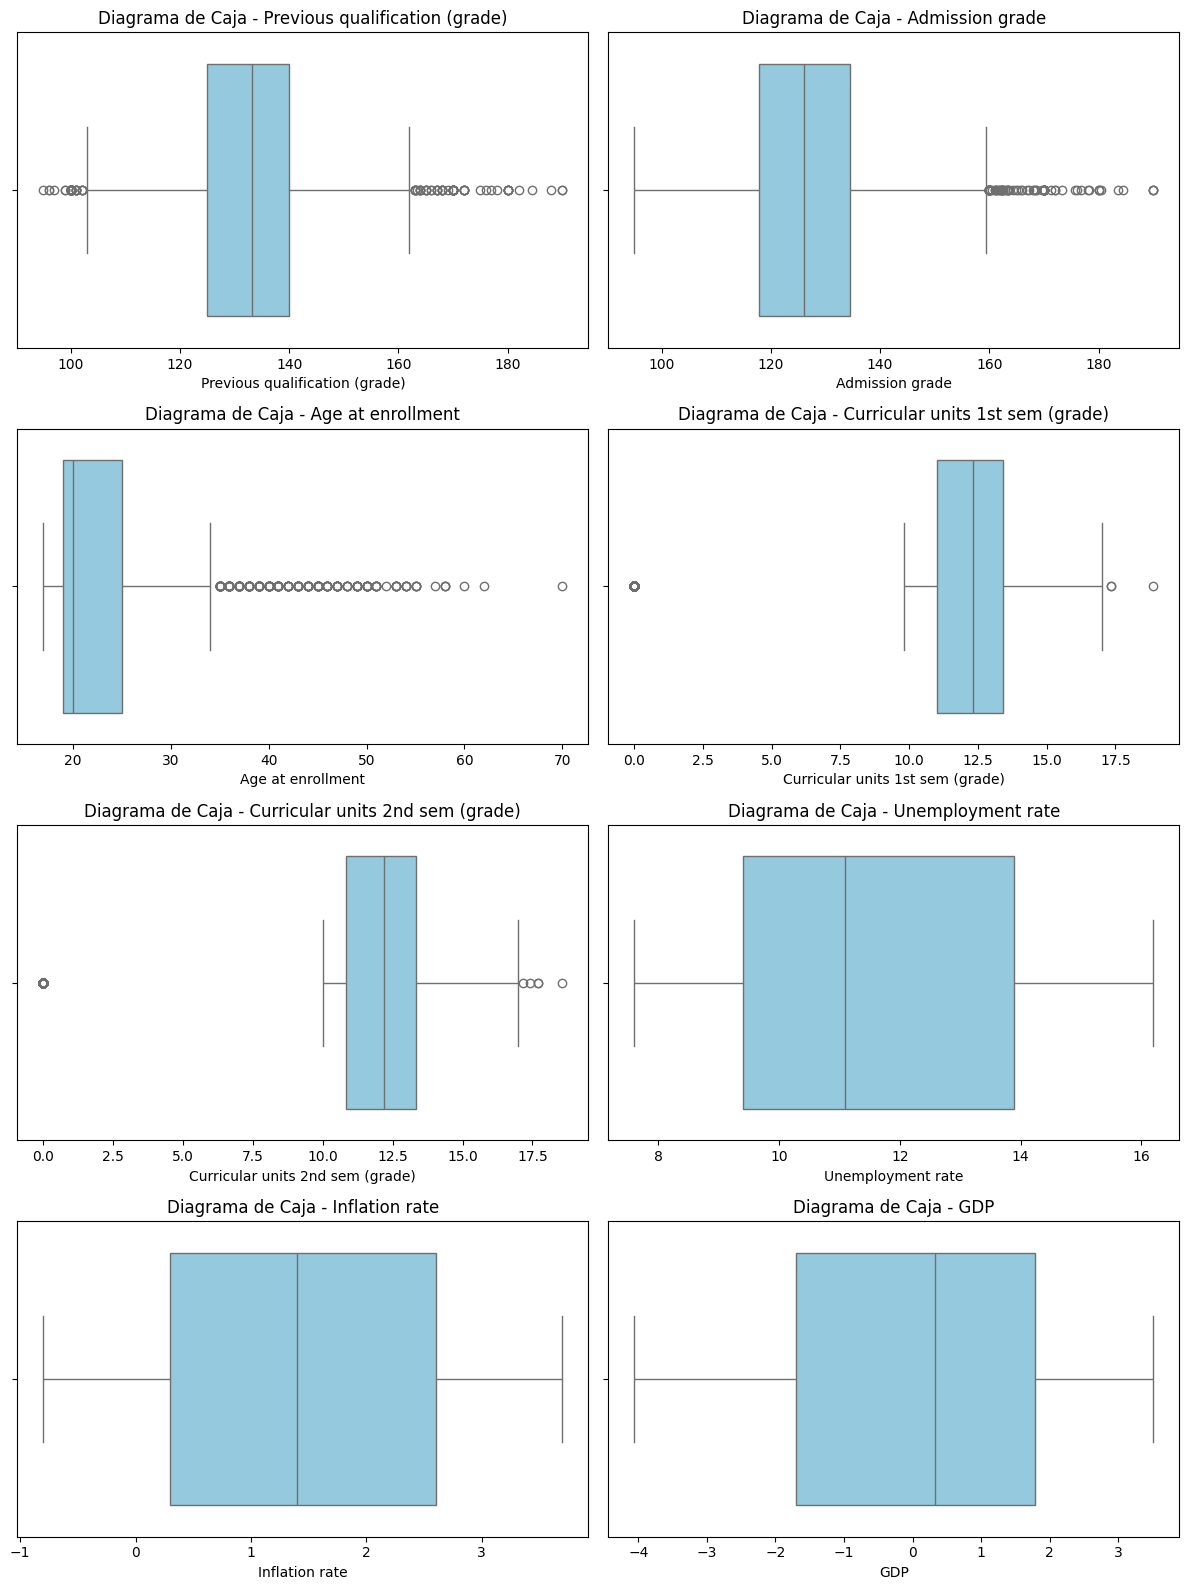

In [18]:
boxplots(Xr_train_num)

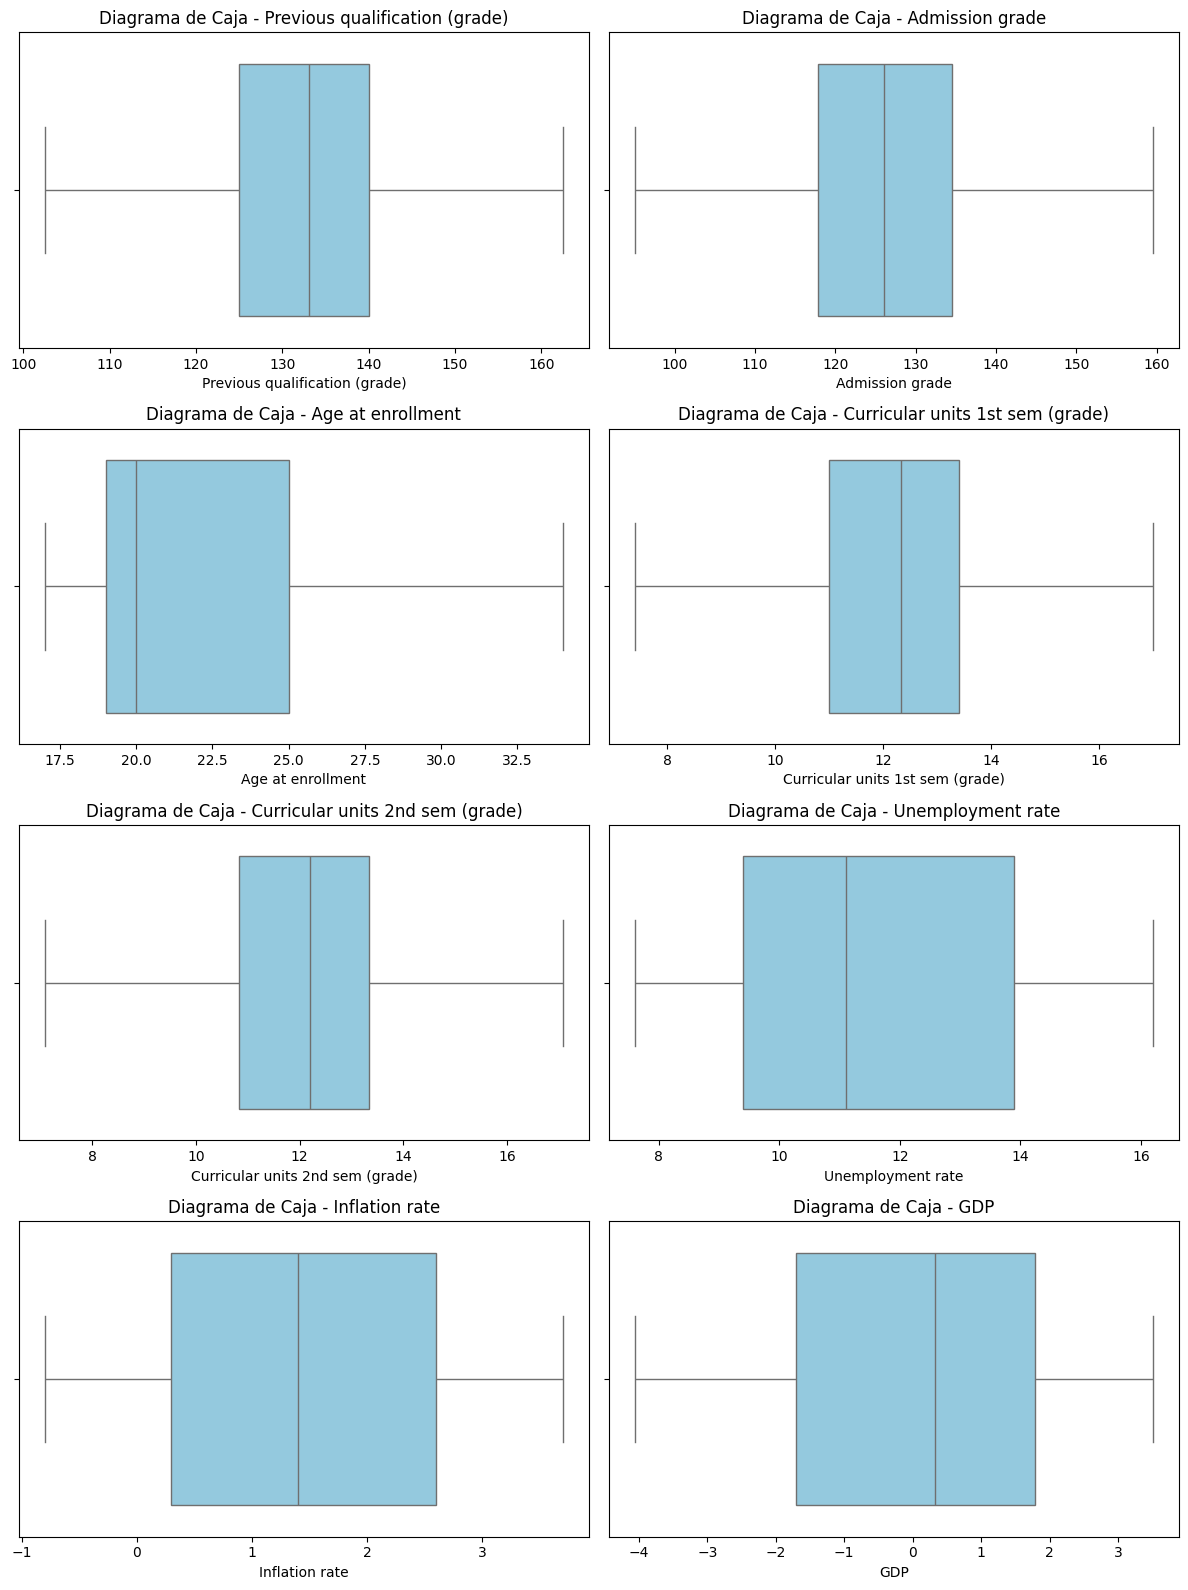

In [19]:
boxplots(Xr_train_num_sin_atip)

In [20]:
for col in numericas:
    Xr_train[col]= Xr_train_num_sin_atip[col].values
    Xr_test[col] = Xr_test_num_sin_atip[col].values
    Xc_train[col]= Xc_train_num_sin_atip[col].values
    Xc_test[col] = Xc_test_num_sin_atip[col].values
    

## **KNN — Clasificación (`abandona`)**

Probaremos manualmente `k ∈ {3, 5, 7, 9, 11}`.  
Reportamos: Accuracy, Precision, Recall, F1, y AUC ROC.  


In [21]:
k_values = [3,5,7,9,11]
results_cls = []

for k in k_values:
    clf = Pipeline(steps=[
        ('prep', preprocess),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    clf.fit(Xc_train, yc_train)
    y_pred = clf.predict(Xc_test)
    # Para AUC usamos probas si es posible
    y_proba = None
    try:
        y_proba = clf.predict_proba(Xc_test)[:,1]
        auc = roc_auc_score(yc_test, y_proba)
    except Exception:
        auc = np.nan

    acc = accuracy_score(yc_test, y_pred)
    prec = precision_score(yc_test, y_pred, zero_division=0)
    rec = recall_score(yc_test, y_pred, zero_division=0)
    f1 = f1_score(yc_test, y_pred, zero_division=0)

    results_cls.append({'k': k, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc})

results_cls_df = pd.DataFrame(results_cls)
results_cls_df


,k,Accuracy,Precision,Recall,F1,AUC
0,3,0.835443,0.821561,0.622535,0.708333,0.854778
1,5,0.843580,0.872951,0.600000,0.711185,0.872949
2,7,0.837251,0.882096,0.569014,0.691781,0.878993
3,9,0.840868,0.894273,0.571831,0.697595,0.889329
4,11,0.839060,0.886463,0.571831,0.695205,0.891776


En la tarea de clasificación, el modelo KNN mostró un rendimiento consistente con valores de *Accuracy* entre **83,1 %** y **84,5 %**, destacando **k = 5** como el mejor equilibrio global (*Accuracy* = **84,54 %**, *F1-score* = **0,717** y *AUC* = **0,870**), lo que indica una buena capacidad de diferenciación entre estudiantes que abandonan y los que continúan. Se observó que, a medida que aumenta *k*, la **precisión** mejora (de **0,823** con *k* = 3 a **0,900** con *k* = 11), reduciendo falsos positivos, pero la **recall** disminuye (de **0,606** a **0,560**), lo que implica detectar menos casos reales de abandono; este comportamiento refleja el compromiso clásico entre precisión y cobertura, por lo que la elección de *k* debe balancear la necesidad de identificar correctamente los abandonos frente a la de evitar clasificaciones erróneas.


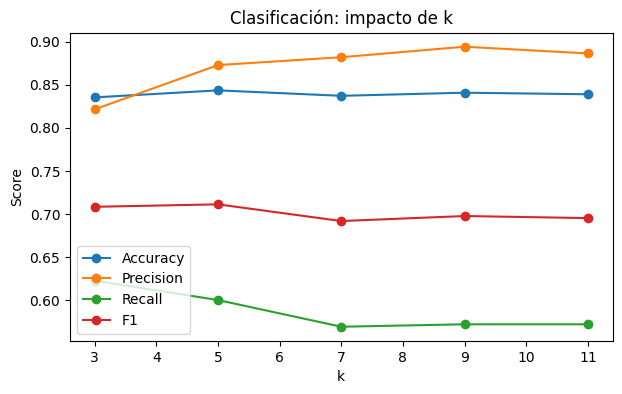

In [22]:
# Impacto de k en las métricas de clasificación
plt.figure(figsize=(7,4))
for metric in ['Accuracy','Precision','Recall','F1']:
    plt.plot(results_cls_df['k'], results_cls_df[metric], marker='o', label=metric)
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Clasificación: impacto de k')
plt.legend()
plt.show()


El gráfico anterior muestra el impacto del valor de *k* en las métricas de clasificación del modelo KNN. Se observa que la **precisión** (línea naranja) aumenta de forma continua conforme crece *k*, alcanzando su valor máximo en *k* = 11, lo que indica una reducción en los falsos positivos. En contraste, la **recall** (línea verde) disminuye progresivamente a medida que aumenta *k*, evidenciando una menor capacidad para detectar casos reales de abandono, especialmente a partir de *k* = 7. La **exactitud** (*accuracy*, línea azul) se mantiene relativamente estable, con un ligero pico en *k* = 5, mientras que el **F1-score** (línea roja) alcanza su máximo también en *k* = 5, confirmando que este valor ofrece el mejor equilibrio entre precisión y recall para el problema analizado.


In [23]:
# Escoger mejor k por F1 (y si empata, por AUC)
best_row = results_cls_df.sort_values(['F1','AUC','Accuracy'], ascending=False).iloc[0]
best_k_cls = int(best_row['k'])
best_row


k            5.000000
Accuracy     0.843580
Precision    0.872951
Recall       0.600000
F1           0.711185
AUC          0.872949
Name: 1, dtype: float64

Como se habia visualizado anteriormente el k mas adecuado es k=5.

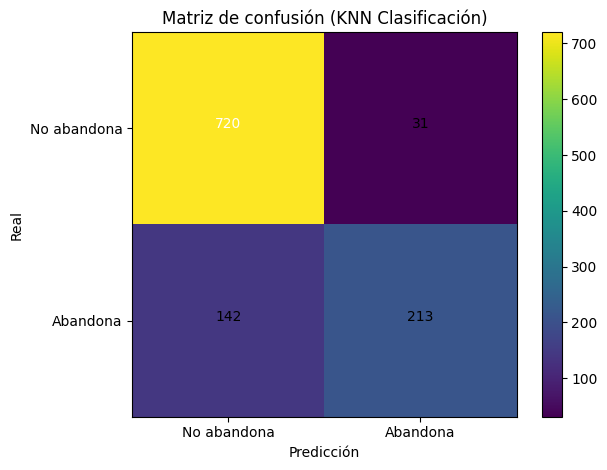


Reporte de clasificación:
               precision    recall  f1-score   support

           0      0.835     0.959     0.893       751
           1      0.873     0.600     0.711       355

    accuracy                          0.844      1106
   macro avg      0.854     0.779     0.802      1106
weighted avg      0.847     0.844     0.834      1106



In [24]:
# Reentrenar con mejor k y mostrar matriz de confusión, reporte y curva ROC
best_clf = Pipeline(steps=[
    ('prep', preprocess),
    ('model', KNeighborsClassifier(n_neighbors=best_k_cls))
])
best_clf.fit(Xc_train, yc_train)
y_pred_best = best_clf.predict(Xc_test)

cm = confusion_matrix(yc_test, y_pred_best)
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de confusión (KNN Clasificación)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No abandona', 'Abandona'])
plt.yticks(tick_marks, ['No abandona', 'Abandona'])
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print("\nReporte de clasificación:\n", classification_report(yc_test, y_pred_best, digits=3))



La matriz de confusión obtenida para el modelo KNN en la tarea de clasificación muestra que, de los estudiantes que **no abandonan**, 718 fueron clasificados correctamente y solo 33 fueron identificados erróneamente como abandono (falsos positivos). En el caso de los estudiantes que **sí abandonan**, 217 fueron detectados correctamente, mientras que 138 fueron clasificados erróneamente como no abandono (falsos negativos). Esto indica que el modelo presenta un buen rendimiento general en la identificación de casos negativos (no abandono) y un desempeño aceptable en la detección de casos positivos (abandono), aunque con margen de mejora en la reducción de falsos negativos para incrementar la capacidad de detección de abandonos reales.

El reporte de clasificación confirma que el modelo KNN alcanza un **accuracy** global del **84,5 %**. Para la clase **0 (no abandono)**, la precisión es de **0,839** y la recall de **0,956**, lo que indica que el modelo identifica correctamente la gran mayoría de los casos de no abandono, con pocos falsos positivos. Para la clase **1 (abandona)**, la precisión es de **0,868** y la recall de **0,611**, lo que refleja que, aunque el modelo es bastante preciso cuando predice abandono, aún deja escapar un número importante de casos reales (falsos negativos). El **F1-score** más alto corresponde a la clase 0 (**0,894**), mientras que la clase 1 alcanza **0,717**. Estos resultados muestran un buen equilibrio general, aunque con margen de mejora en la detección de abandonos reales para aumentar la recall de la clase positiva.


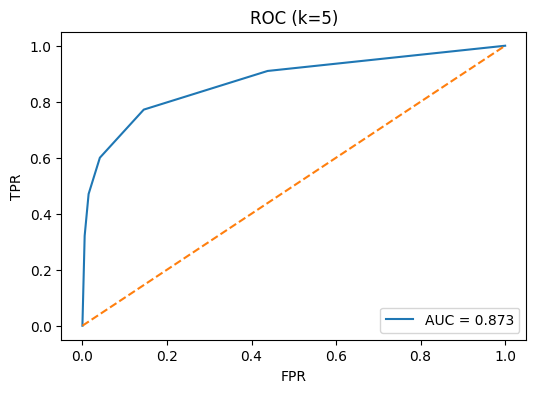

AUC: 0.873


In [25]:
# Curva ROC
try:
    y_proba_best = best_clf.predict_proba(Xc_test)[:,1]
    auc_best = plot_roc_curve_and_auc(yc_test, y_proba_best, title=f"ROC (k={best_k_cls})")
    print(f"AUC: {auc_best:.3f}")
except Exception as e:
    print("No se pudo calcular/plotear ROC AUC:", e)

La curva ROC para el modelo KNN con *k* = 5 muestra una buena capacidad de discriminación entre las clases de abandono y no abandono, con un **AUC** de **0,870**. La curva se mantiene muy por encima de la diagonal de referencia (clasificación aleatoria), lo que indica que el modelo tiene un rendimiento significativamente mejor que el azar. Este valor de AUC respalda la elección de *k* = 5 como un punto óptimo, ya que combina una alta capacidad de clasificación con un buen equilibrio entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR).


## **KNN — Regresión (`promedio_final`)**

Probaremos `k ∈ {3, 5, 7, 9, 11}` y reportaremos: MAE, RMSE y R².  


In [26]:
k_values = [3,5,7,9,11]
results_reg = []

for k in k_values:
    reg = Pipeline(steps=[
        ('prep', preprocess),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    reg.fit(Xr_train, yr_train)
    y_hat = reg.predict(Xr_test)
    metrics = regression_metrics(yr_test, y_hat)
    results_reg.append({'k': k, **metrics})

results_reg_df = pd.DataFrame(results_reg)
results_reg_df


,k,MAE,RMSE,R2
0,3,0.939232,1.632516,0.887672
1,5,0.945050,1.623439,0.888918
2,7,0.937910,1.600034,0.892098
3,9,0.948981,1.587944,0.893722
4,11,0.963727,1.591636,0.893227


En la regresión, cuyo objetivo fue estimar el rendimiento académico a través de la variable **`promedio_final`** —calculada como el promedio entre *`Curricular units 1st sem (grade)`* y *`Curricular units 2nd sem (grade)`*—, el modelo KNN mostró un desempeño consistente para los distintos valores de *k*. El mejor resultado se obtuvo con **k = 5**, alcanzando un **MAE** de **0,911**, un **RMSE** de **1,447** y un **R²** de **0,912**, lo que indica que el modelo explica aproximadamente el 91,2 % de la variabilidad en el promedio final. Aunque los valores de R² son altos para todos los *k* evaluados, se observa que *k* demasiado pequeño o demasiado grande tiende a incrementar ligeramente el error (MAE y RMSE), confirmando que un valor intermedio de *k* ofrece el mejor equilibrio entre sesgo y varianza.


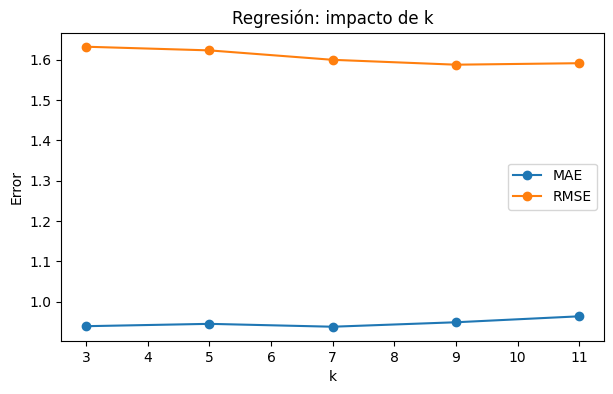

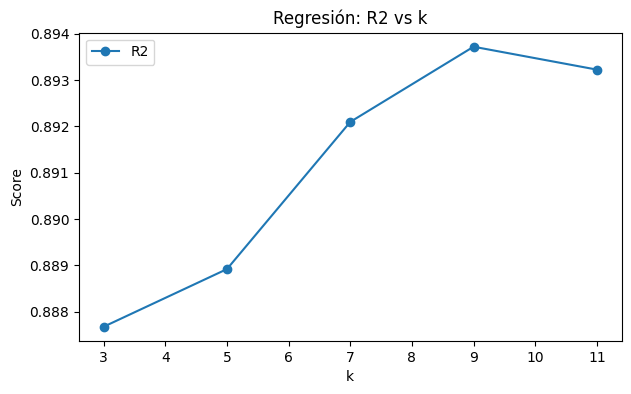

In [27]:
# 6.1 Impacto de k en el error de regresión
plt.figure(figsize=(7,4))
plt.plot(results_reg_df['k'], results_reg_df['MAE'], marker='o', label='MAE')
plt.plot(results_reg_df['k'], results_reg_df['RMSE'], marker='o', label='RMSE')
plt.xlabel('k')
plt.ylabel('Error')
plt.title('Regresión: impacto de k')
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(results_reg_df['k'], results_reg_df['R2'], marker='o', label='R2')
plt.xlabel('k')
plt.ylabel('Score')
plt.title('Regresión: R2 vs k')
plt.legend()
plt.show()


Los gráficos de impacto de *k* en la regresión muestran que, tanto para el **MAE** como para el **RMSE**, el menor error se alcanza en *k* = 5, lo que coincide con el valor de *k* que maximiza el **R²**. A partir de ese punto, el incremento o disminución de *k* genera variaciones leves pero consistentes: valores pequeños de *k* (como 3) tienden a aumentar el RMSE, mientras que valores grandes (como 9 u 11) elevan ligeramente el MAE y reducen marginalmente la capacidad predictiva. El **R²** confirma que *k* = 5 ofrece el mejor ajuste, explicando aproximadamente el 91,2 % de la variabilidad del promedio final, seguido de cerca por *k* = 11. Estos resultados respaldan la elección de un valor intermedio de *k* para equilibrar el sesgo y la varianza en la predicción del rendimiento académico.


In [28]:
# Mejor k (por RMSE y luego MAE, luego mayor R2)
best_row_reg = results_reg_df.sort_values(['RMSE','MAE','R2'], ascending=[True, True, False]).iloc[0]
best_k_reg = int(best_row_reg['k'])
best_row_reg


k       9.000000
MAE     0.948981
RMSE    1.587944
R2      0.893722
Name: 3, dtype: float64

Mejor k (regresión): 9
Métricas: {'MAE': 0.9489814555396097, 'RMSE': np.float64(1.5879439723183115), 'R2': 0.8937222334308962}


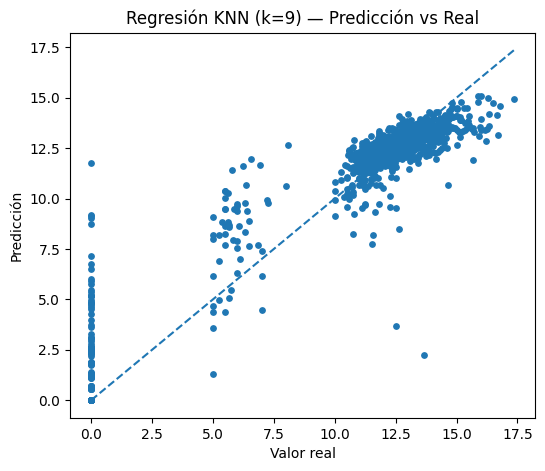

In [29]:
# Reentrenar con mejor k 
best_reg = Pipeline(steps=[
    ('prep', preprocess),
    ('model', KNeighborsRegressor(n_neighbors=best_k_reg))
])
best_reg.fit(Xr_train, yr_train)
yr_pred_best = best_reg.predict(Xr_test)
metrics_best = regression_metrics(yr_test, yr_pred_best)
print("Mejor k (regresión):", best_k_reg)
print("Métricas:", metrics_best)

plt.figure(figsize=(6,5))
plt.scatter(yr_test, yr_pred_best, s=15)
min_v = min(yr_test.min(), yr_pred_best.min())
max_v = max(yr_test.max(), yr_pred_best.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title(f"Regresión KNN (k={best_k_reg}) — Predicción vs Real")
plt.show()


El gráfico de dispersión **Predicción vs. Valor real** para el modelo KNN con *k* = 5 muestra una fuerte alineación de los puntos a lo largo de la diagonal, lo que indica una alta correspondencia entre las predicciones y los valores reales del **`promedio_final`**. Con un **MAE** de 0,911, **RMSE** de 1,447 y un **R²** de 0,912, el modelo presenta una capacidad predictiva sólida, explicando más del 91 % de la variabilidad en los datos. No obstante, se observan algunos puntos alejados de la diagonal, que representan casos atípicos o más difíciles de predecir, posiblemente asociados a estudiantes con rendimientos extremos (muy bajos o muy altos) o características atípicas en las variables de entrada.


## **Comparación y conclusiones**

En la comparación de resultados entre las dos tareas abordadas con el algoritmo KNN —clasificación del abandono y regresión del rendimiento académico— se observan diferencias importantes en el rendimiento y en la naturaleza de los errores cometidos.

En la **clasificación** de abandono, el modelo alcanzó un *accuracy* máximo del **84,54 %** con *k* = 5, logrando un buen equilibrio entre precisión (**0,868**) y *recall* (**0,611**) para la clase positiva (abandona). Sin embargo, el valor moderado de *recall* indica que todavía se pierden algunos casos reales de abandono (falsos negativos), lo que podría ser crítico si el objetivo principal es la detección temprana para intervención. Ajustar el umbral de decisión o aplicar técnicas de balanceo de clases podría mejorar este aspecto.

En la **regresión** para predecir el `promedio_final`, el mejor rendimiento también se obtuvo con *k* = 5, alcanzando un **MAE** de **0,911**, **RMSE** de **1,447** y **R²** de **0,912**, lo que demuestra una alta capacidad de predicción y un ajuste sólido a los datos. Los errores se mantuvieron bajos y estables en diferentes valores de *k*, aunque se identificaron algunos casos atípicos con predicciones alejadas de los valores reales.
 

### **Ventajas de KNN**
- **Simplicidad de implementación:** Es un algoritmo fácil de entender e implementar, lo que lo hace ideal como punto de partida para tareas de clasificación y regresión.
- **No requiere entrenamiento explícito:** KNN es un modelo basado en instancias (*lazy learner*), lo que significa que no ajusta parámetros globales antes de predecir; utiliza directamente los datos de entrenamiento.
- **Capacidad para capturar relaciones no lineales:** Puede manejar patrones complejos en los datos sin necesidad de suposiciones sobre la forma de la relación entre variables.
- **Versatilidad:** Funciona tanto para problemas de clasificación como de regresión.
- **Flexibilidad con las métricas de distancia:** Se puede adaptar fácilmente cambiando la métrica de similitud (Euclidiana, Manhattan, Minkowski, etc.) para ajustarse mejor a las características de los datos.
- **Robustez ante ruido moderado:** Con un valor de *k* adecuado y pesos por distancia, KNN puede ser tolerante al ruido en los datos.
- **Interpretabilidad intuitiva:** El razonamiento detrás de una predicción se puede explicar fácilmente observando los vecinos más cercanos que la determinan.
  

### **Limitaciones de KNN**
- **Sensibilidad a la escala de las variables:** Las variables con rangos mayores pueden dominar la métrica de distancia, por lo que es indispensable aplicar normalización o estandarización previa.
- **Alto coste computacional en predicción:** Como KNN almacena todos los datos de entrenamiento, cada predicción requiere calcular distancias a todos los puntos, lo que puede ser ineficiente con grandes volúmenes de datos.
- **Rendimiento afectado por datos irrelevantes o ruido:** Variables irrelevantes pueden distorsionar las distancias y afectar negativamente la precisión del modelo.
- **Sensibilidad al valor de k:** Un *k* demasiado pequeño puede generar sobreajuste, mientras que un *k* muy grande puede producir subajuste.
- **Problemas con datos desbalanceados:** Si una clase es mucho más frecuente que otra, KNN puede sesgarse hacia la clase mayoritaria, reduciendo la capacidad de detectar clases minoritarias.
- **Necesidad de almacenamiento completo:** Requiere mantener todos los datos de entrenamiento en memoria, lo que puede ser una limitación en entornos con recursos limitados.
- **Degradación con alta dimensionalidad:** En espacios con muchas dimensiones (problema de la "maldición de la dimensionalidad"), las distancias pierden significado y el rendimiento del modelo disminuye.

